In [212]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,recall_score,roc_curve,auc

In [213]:
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")

In [214]:
path

'C:\\Users\\HP\\.cache\\kagglehub\\datasets\\yasserh\\breast-cancer-dataset\\versions\\1'

In [215]:
os.listdir(path)

['breast-cancer.csv']

In [216]:
data=pd.read_csv(path+"/breast-cancer.csv")

In [217]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [218]:
data.shape

(569, 32)

In [219]:
data.isnull().sum() #no null values

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [220]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [221]:
data['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [222]:
data['diagnosis']=data['diagnosis'].map({'M':1,'B':0})

In [223]:
# removing worst features

In [224]:
data=data.drop('id',axis=1)

In [225]:
# outliers

In [226]:
numeric_cols=data.select_dtypes(include=['float64','int64']).columns

In [227]:
outliers={}

In [228]:
for col in numeric_cols:
    q1=data[col].quantile(0.25) #25th %ile
    q3=data[col].quantile(0.75) #75th %ile

    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    outliers_rows=data[(data[col]>upper) | (data[col]<lower)]
    outliers[col]=outliers_rows

In [229]:
for feature in outliers:
    print(feature,len(outliers[feature]))

diagnosis 0
radius_mean 14
texture_mean 7
perimeter_mean 13
area_mean 25
smoothness_mean 6
compactness_mean 16
concavity_mean 18
concave points_mean 10
symmetry_mean 15
fractal_dimension_mean 15
radius_se 38
texture_se 20
perimeter_se 38
area_se 65
smoothness_se 30
compactness_se 28
concavity_se 22
concave points_se 19
symmetry_se 27
fractal_dimension_se 28
radius_worst 17
texture_worst 5
perimeter_worst 15
area_worst 35
smoothness_worst 7
compactness_worst 16
concavity_worst 12
concave points_worst 0
symmetry_worst 23
fractal_dimension_worst 24


In [230]:
outliers_rows['diagnosis'].value_counts()

diagnosis
1    18
0     6
Name: count, dtype: int64

In [231]:
corr_matrix=data[numeric_cols].corr()

In [232]:
corr_matrix

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


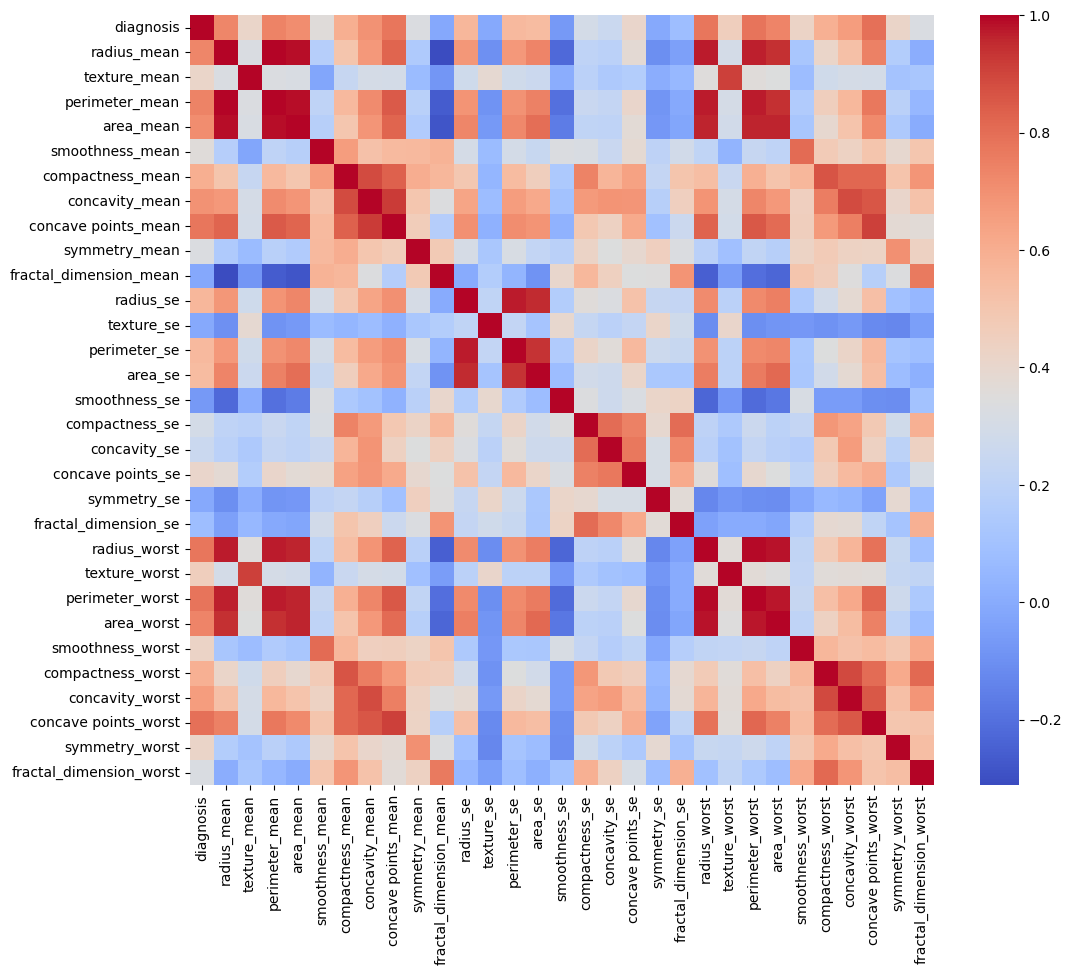

In [233]:
#heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,cmap='coolwarm')
plt.show()

In [234]:
threshold=0.9

In [235]:
# upper
upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

In [236]:
dropi=[column for column in upper.columns if any(upper[column].abs()>threshold)]

In [237]:
data=data.drop(columns=dropi)

In [238]:
#train test split

In [239]:
x=data.drop(columns='diagnosis')
y=data['diagnosis']

In [240]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [241]:
#scaling

In [242]:
scaler=StandardScaler()

In [243]:
xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.transform(xtest)

In [244]:
# model training

In [245]:
#hyper parameter tuning

In [246]:
scores=[]

In [247]:
for i in range(1,22):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(xtrain_scaled,ytrain)
    ypred=knn.predict(xtest_scaled)
    scores.append(recall_score(ytest,ypred))

In [248]:
scores.index(max(scores))+1

7

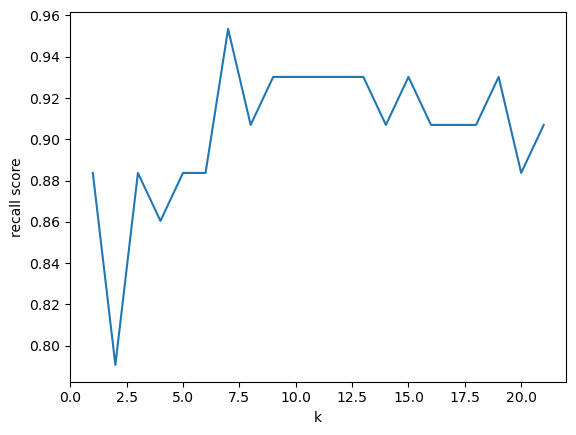

In [249]:
plt.plot(range(1,22),scores)
plt.xlabel('k')
plt.ylabel('recall score')
plt.show()

In [250]:
cv_scores=[]

In [251]:
for i in range(1,22):
    knn=KNeighborsClassifier(n_neighbors=i)
    scores=cross_val_score(knn,xtrain_scaled,ytrain,cv=5)
    cv_scores.append(scores.mean())

In [252]:
cv_scores

[np.float64(0.9340659340659341),
 np.float64(0.9318681318681319),
 np.float64(0.956043956043956),
 np.float64(0.945054945054945),
 np.float64(0.9538461538461538),
 np.float64(0.9384615384615385),
 np.float64(0.9494505494505494),
 np.float64(0.9406593406593406),
 np.float64(0.9384615384615385),
 np.float64(0.9340659340659341),
 np.float64(0.9362637362637363),
 np.float64(0.9406593406593406),
 np.float64(0.9406593406593406),
 np.float64(0.9362637362637363),
 np.float64(0.9318681318681319),
 np.float64(0.9340659340659341),
 np.float64(0.9362637362637363),
 np.float64(0.9340659340659341),
 np.float64(0.9362637362637363),
 np.float64(0.9340659340659341),
 np.float64(0.9362637362637363)]

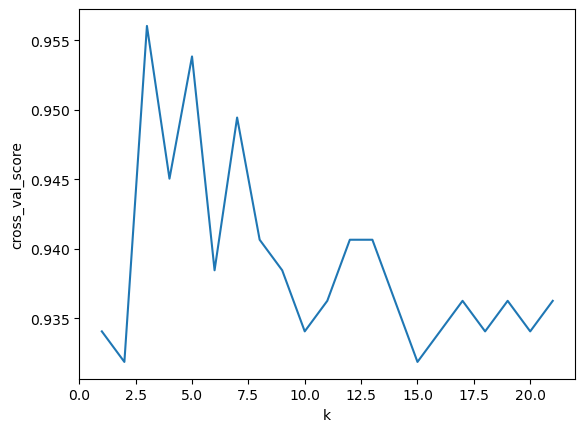

In [253]:
plt.plot(range(1,22),cv_scores)
plt.xlabel('k')
plt.ylabel('cross_val_score')
plt.show()

In [254]:
knn=KNeighborsClassifier(n_neighbors=7)

In [255]:
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(n_neighbors=7)

In [256]:
ypred=knn.predict(xtest_scaled)

In [257]:
confusion_matrix(ytest,ypred)

array([[68,  3],
       [ 2, 41]])

In [258]:
recall_score(ytest,ypred)

0.9534883720930233

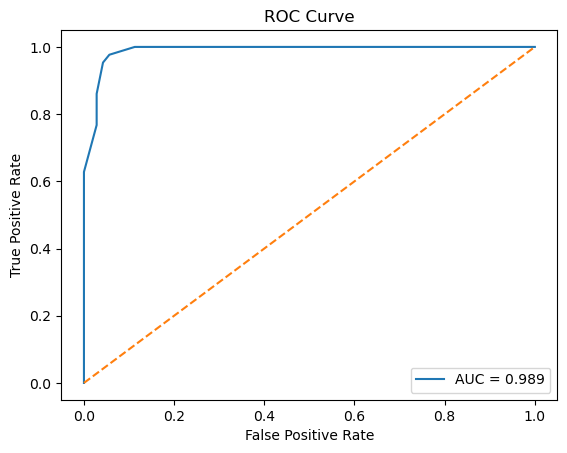

In [260]:
y_prob = knn.predict_proba(xtest_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(ytest, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,3)))
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig('roc_curve.png',dpi=300)
plt.show()